In [1]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from azure.ai.vision.imageanalysis.models import VisualFeatures

from msrest.authentication import CognitiveServicesCredentials
import time
import matplotlib.pyplot as plt
import json
from pathlib import Path
import math
import shapely

# Authentificate

In [2]:
'''
Authenticate
Authenticates your credentials and creates a client.
'''
credidential = json.load(open("credidentiale.json"))
subscription_key = credidential["API_KEY"]
endpoint = credidential["END_POINT"]
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

'\nEND - Authenticate\n'

# 1. Sa se foloseasca un algoritm de clasificare a imaginilor (etapa de inferenta/testare) si sa se stabileasca performanta acestui algoritm de clasificare binara (imagini cu biciclete vs. imagini fara biciclete).

## Daca functia contine sau nu o bicicleta

In [3]:
def containsByke(path):
    time.sleep(1)
    img = open(path, "rb")
    result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])

    for ob in result.objects:
        if ob.object_property == "bicycle" or ob.object_property == "cycle":
            return True

    return False

## Verificam Clasificarea binara

![Matricea de confuzie](https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2024-2025/labs/lab04/images/cm.png)
## - acuratea : reprezinta performanta modelului :
    $$acc = \frac{TP + TN}{TP + TN + FP + FN} = \frac{correc predicted}{no of all samples}$$
## - precisia indica cate de bune sunt predictile
    $$precision = \frac{TP}{TP+FP}$$
## - recall indica cate valori de adevar a acoperit cu adevarat
    $$recall = \frac{TP}{TP+FN}$$

In [4]:
def binary_classification():
    image_dir = Path('biciclete')
    image_files = [file for file in image_dir.iterdir()]

    predicted_values = [containsByke(file) for file in image_files]
    true_values = [True] * 10 + [False] * 10
    print_str = [f"Imaginea_{i+1} : {predicted_values[i]} <-|-> {true_values[i]}"
                 for i in range(len(true_values))]
    
    print("Imagine : predicted values  <-|->   true value")
    for str in print_str:
        print(str)
    print()
    
    TP = sum([1 if (predicted_values[i] == True and true_values[i] == True) else 0 for i in range(len(true_values))])
    FP = sum([1 if (predicted_values[i] == True and true_values[i] != True) else 0 for i in range(len(true_values))])
    TN = sum([1 if (predicted_values[i] != True and true_values[i] != True) else 0 for i in range(len(true_values))])
    FN = sum([1 if (predicted_values[i] != True and true_values[i] == True) else 0 for i in range(len(true_values))])

    print(f"TN:{TN} | FP:{FP}\n--------\nFN:{FN} | TP:{TP}")
    print()
    
    acc = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TN / (TN + FP)
    
    return acc,precision,recall

In [5]:
acc,precision,recall = binary_classification()
print('acc: ', acc, '\nprecision: ', precision, '\nrecall: ', recall)

Imagine : predicted values  <-|->   true value
Imaginea_1 : True <-|-> True
Imaginea_2 : True <-|-> True
Imaginea_3 : True <-|-> True
Imaginea_4 : True <-|-> True
Imaginea_5 : True <-|-> True
Imaginea_6 : True <-|-> True
Imaginea_7 : True <-|-> True
Imaginea_8 : True <-|-> True
Imaginea_9 : False <-|-> True
Imaginea_10 : True <-|-> True
Imaginea_11 : False <-|-> False
Imaginea_12 : False <-|-> False
Imaginea_13 : False <-|-> False
Imaginea_14 : False <-|-> False
Imaginea_15 : False <-|-> False
Imaginea_16 : False <-|-> False
Imaginea_17 : False <-|-> False
Imaginea_18 : False <-|-> False
Imaginea_19 : False <-|-> False
Imaginea_20 : False <-|-> False

TN:10 | FP:0
--------
FN:1 | TP:9

acc:  0.95 
precision:  1.0 
recall:  1.0


# 2.Pentru imaginile care contin biciclete:
## a. sa se localizeze automat bicicletele in aceste imagini si sa se evidentieze chenarele care incadreaza bicicletele
## b. sa se eticheteze (fara ajutorul algoritmilor de AI) aceste imagini cu chenare care sa incadreze cat mai exact bicicletele. Care task dureaza mai mult (cel de la punctul a sau cel de la punctul b)?
## c. sa se determine performanta algoritmului de la punctul a avand in vedere etichetarile realizate la punctul b (se vor folosi cel putin 2 metrici).

In [6]:
def byke_reg(path, byke_rec):
    img = open(path, "rb")
    predicted_byke = [0,0,0,0]
    result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
    for ob in result.objects:
        if ob.object_property == "bicycle" or ob.object_property == "cycle":
            predicted_byke = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w,
                              ob.rectangle.y + ob.rectangle.h]

    im = plt.imread(path)
    plt.clf()
    fig = plt.imshow(im)
    
    fig.axes.add_patch(
        plt.Rectangle(xy=(byke_rec['x'], byke_rec['y']), width=byke_rec['width'], height=byke_rec['height'], fill=False,
                      color="green", linewidth=2))
    fig.axes.add_patch(
        plt.Rectangle(xy=(predicted_byke[0], predicted_byke[1]), width=predicted_byke[2] - predicted_byke[0],
                      height=predicted_byke[3] - predicted_byke[1], fill=False, color="red", linewidth=2))

    plt.axis('off')
    plt.text(byke_rec['x'], byke_rec['y'] - 30, 'trueBox', color='green')
    plt.text(predicted_byke[2] - 100, predicted_byke[3] + 20, 'predictedBox', color='red')
    plt.savefig('boxbike/' + path.split('/')[1] + '_box.png')
    plt.show()
    
    return predicted_byke, byke_rec

## Incadrez bicicletele cu [annnotate](https://annotate.officialstatistics.org) din care importez figura ca si json , pe care ii voi extrage coltul stanga sus , latime , lungime si desenez dupa chenarul.

In [7]:
def json_byke(path):
    name = path.split('/')[1]
    with open('bikes_json/'+name+'.json', 'r') as file:
        data = json.load(file)
    
    byke_rec = {}
    
    for key, value in data['_via_img_metadata'].items():
        for region in value['regions']:
            byke_rec['x'] = region['shape_attributes']['x']
            byke_rec['y'] = region['shape_attributes']['y']
            byke_rec['width'] = region['shape_attributes']['width']
            byke_rec['height'] = region['shape_attributes']['height']
            
    return byke_rec

## Metricele de distanta:
### - Jaccard Index :
    $$jaccard = \frac{ |A \bigcap B| }{|A \bigcup B|}$$

### - DIOU - adaugaa o cutie in jurul Chenarelor
    $$diou = \frac{ |A \bigcap B| }{|A \bigcup B|} - \frac{eu_mij^2}{d^2}$$
    
Cu eu_mij - distanta euclidiana dintre mijlocurile A si B
d - diagonala dreptughiului de aria minima ce contine pe A si B
### Functia ajutatoare de puncte si arii

In [8]:
def intersection_reunion (l1, r1, l2, r2):
    area1 = abs(l1[0] - r1[0]) * abs(l1[1] - r1[1])
    area2 = abs(l2[0] - r2[0]) * abs(l2[1] - r2[1])

    width = (min(r1[0], r2[0]) -
              max(l1[0], l2[0]))
 
    height = (min(r1[1], r2[1]) -
              max(l1[1], l2[1]))
    
    areaI = 0
    if width > 0 and height > 0:
        areaI = width * height
 
    return areaI, area1 + area2 - areaI

def Puncte(Aibox, RealBox):
    l1 = (Aibox[0],Aibox[1])
    r1 = (Aibox[2],Aibox[3])
    
    l2 = (RealBox['x'],RealBox['y'])
    r2 = (RealBox['x'] + RealBox['width'],RealBox['y'] + RealBox['height'])
    
    return l1,r1,l2,r2

def jaccard_index(Aibox,RealBox):
    l1,r1,l2,r2 = Puncte(Aibox,RealBox)
    i,r = intersection_reunion(l1,r1,l2,r2) 
    return i/r

def diou(Aibox,RealBox):
    l1,r1,l2,r2 = Puncte(Aibox,RealBox)
    i,r = intersection_reunion(l1,r1,l2,r2) 
    M1 = Aibox[0] + (Aibox[2]-Aibox[0])/2
    M2 = Aibox[1] + (Aibox[3]-Aibox[1])/2
    N1 = RealBox['x'] + RealBox['width']/2
    N2 = RealBox['y'] + RealBox['height']/2
    euclidian = (M1-N1)**2 + (M2-N2)**2
    D1 = min(Aibox[0],RealBox['x'])
    D2 = min(Aibox[1],RealBox['y'])
    D3 = max(Aibox[2],RealBox['x']+RealBox['width'])
    D4 = max(Aibox[3],RealBox['y']+RealBox['height'])
    dialog = (D1-D3)**2 + (D2-D4)**2
    
    return i/r - euclidian / dialog

## Analiza imaginilor :

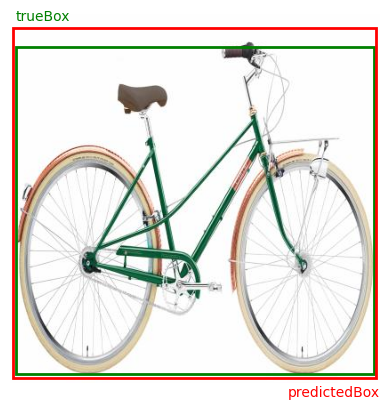

JaccardIndex for this bike1.jpg : 0.920308291859556
Diou for this bike1.jpg : 0.9201098527075113


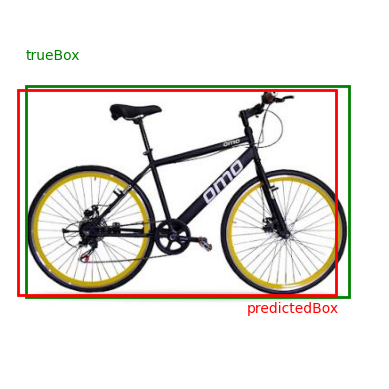

JaccardIndex for this bike2.jpg : 0.9149189704480457
Diou for this bike2.jpg : 0.9142340671055118


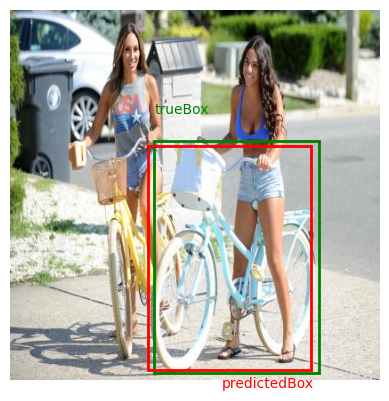

JaccardIndex for this bike3.jpg : 0.8861715518791584
Diou for this bike3.jpg : 0.8855405093492732


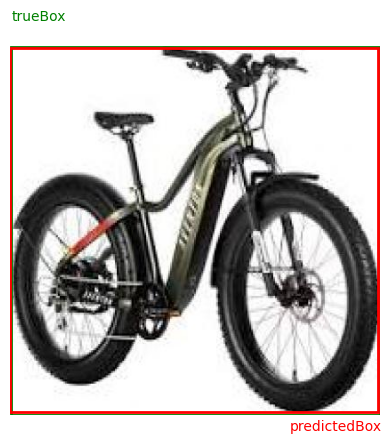

JaccardIndex for this bike4.jpg : 0.9832191383114621
Diou for this bike4.jpg : 0.9832097030345586


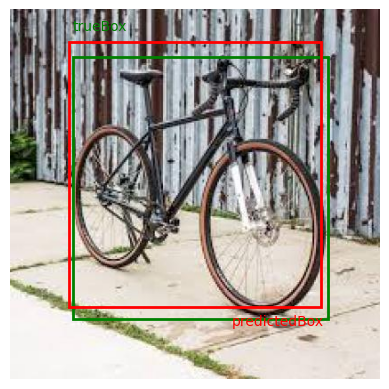

JaccardIndex for this bike5.jpg : 0.8683722572954836
Diou for this bike5.jpg : 0.8669383883214415


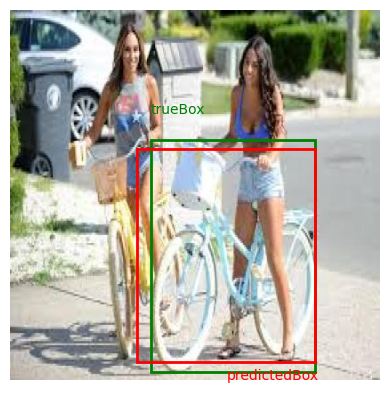

JaccardIndex for this bike6.jpg : 0.8557386527898236
Diou for this bike6.jpg : 0.8552160901054238


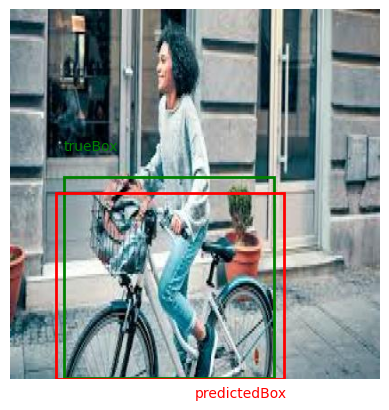

JaccardIndex for this bike7.jpg : 0.8505563568926438
Diou for this bike7.jpg : 0.8497832680107209


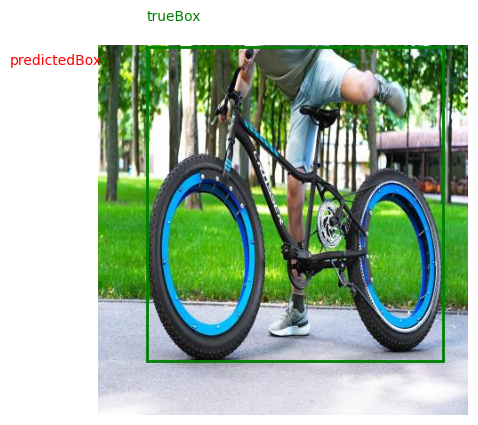

JaccardIndex for this bike8.jpg : 0.0
Diou for this bike8.jpg : -0.29117475362045586


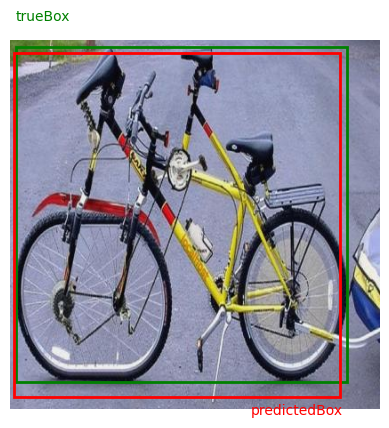

JaccardIndex for this bike9.jpg : 0.9174333681115432
Diou for this bike9.jpg : 0.916901868522209


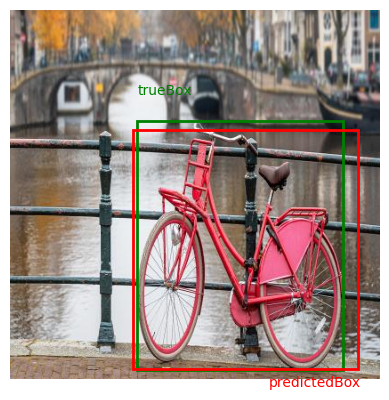

JaccardIndex for this bike10.jpg : 0.8801807416640698
Diou for this bike10.jpg : 0.8797857525833235


In [10]:
image_files = ["biciclete/bike" + str(i) + ".jpg" for i in range(1,11)]

for file in image_files:
    AiB, RealB = byke_reg(file,json_byke(file))
    print(f"JaccardIndex for this {file.split('/')[1]} : {jaccard_index(AiB,RealB)}")
    print(f"Diou for this {file.split('/')[1]} : {diou(AiB,RealB)}")
    